In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras import losses, optimizers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


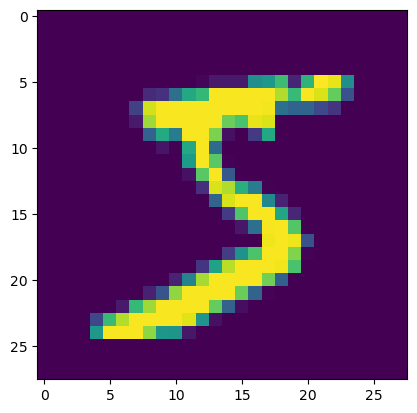

In [3]:
single_image = x_train[0]
plt.imshow(single_image)

In [4]:
y_train_OHE = to_categorical(y_train, num_classes=10)
y_test_OHE = to_categorical(y_test, num_classes=10)


In [5]:
#normalizing

x_train = x_train / 255
x_test = x_test / 255

In [6]:
x_train = x_train.reshape(60000, 28, 28, 1)
x_test = x_test.reshape(10000, 28, 28, 1)

In [7]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(60000, 28, 28, 1) (60000,)
(10000, 28, 28, 1) (10000,)


In [8]:
model = Sequential(
    [
        Conv2D(filters=32, kernel_size=(4, 4), input_shape=(28, 28, 1), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dense(10, activation='softmax')
    ]
)

In [9]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(monitor='val_loss', patience=1)

In [11]:
model.fit(x_train, y_train_OHE, epochs=10, validation_data=(x_test, y_test_OHE),
         callbacks=[early_stop])

Epoch 1/10
1875/1875 [==============================] - 22s 11ms/step - loss: 0.1402 - accuracy: 0.9580 - val_loss: 0.0546 - val_accuracy: 0.9831
Epoch 2/10
1875/1875 [==============================] - 25s 14ms/step - loss: 0.0482 - accuracy: 0.9851 - val_loss: 0.0469 - val_accuracy: 0.9841
Epoch 3/10
1875/1875 [==============================] - 25s 13ms/step - loss: 0.0318 - accuracy: 0.9904 - val_loss: 0.0377 - val_accuracy: 0.9875
Epoch 4/10
1875/1875 [==============================] - 26s 14ms/step - loss: 0.0216 - accuracy: 0.9931 - val_loss: 0.0356 - val_accuracy: 0.9877
Epoch 5/10
1875/1875 [==============================] - 23s 12ms/step - loss: 0.0150 - accuracy: 0.9952 - val_loss: 0.0389 - val_accuracy: 0.9869


<Axes: >

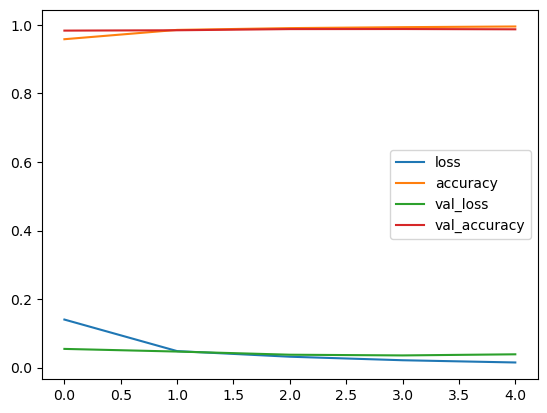

In [12]:
metrics = pd.DataFrame(model.history.history)
metrics[['loss', 'accuracy', 'val_loss', 'val_accuracy']].plot()

In [13]:
model.metrics_names

['loss', 'accuracy']

In [14]:
model.evaluate(x_test, y_test_OHE, verbose=0)

[0.03886711224913597, 0.9868999719619751]

In [15]:
predictions = model.predict(x_test)

313/313 [==============================] - 2s 6ms/step


In [16]:
predictions = np.argmax(predictions, axis=1)

In [17]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.97      0.98      1032
           3       0.98      1.00      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.98       892
           6       0.99      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



<Axes: >

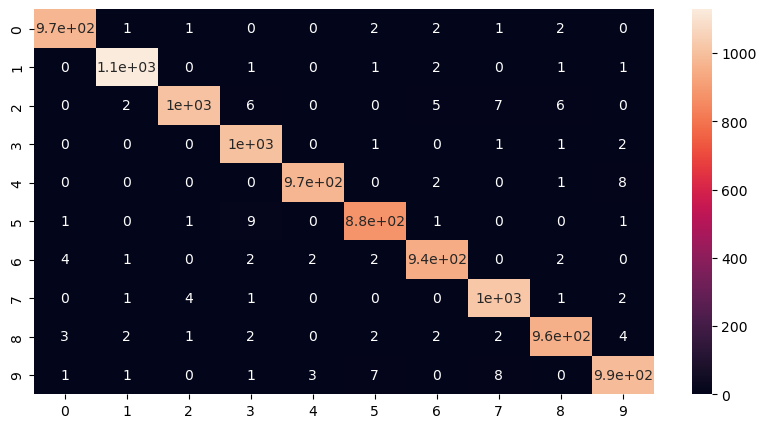

In [18]:
plt.figure(figsize=(10, 5))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

In [19]:
my_number = x_test[0]

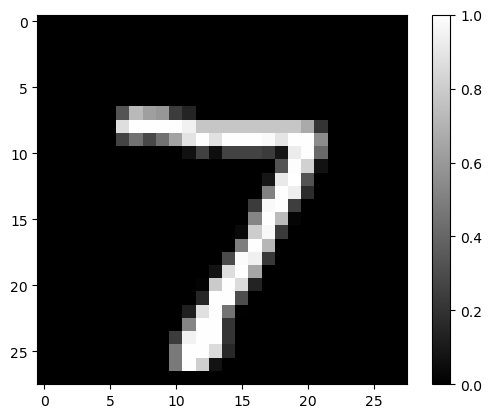

In [20]:
plt.imshow(my_number.reshape(28, 28), cmap='gray')  # ✅ Correct
plt.colorbar()
plt.show()


In [21]:
# Ensure the input has the correct shape (batch size, height, width, channels)
my_number_reshaped = my_number.reshape(1, 28, 28, 1)  # Add batch dimension

# Make a prediction
prediction = model.predict(my_number_reshaped)

# Get the class with the highest probability
predicted_class = np.argmax(prediction)

# Print the predicted class
print(f"Predicted Class: {predicted_class}")


1/1 [==============================] - 0s 29ms/step
Predicted Class: 7
